# C09 · Job training: can observational data stand in for an experiment?

| | |
|---|---|
| **Difficulty** | ★★★★☆ |
| **Time** | 4-5 hours |
| **Data** | LaLonde (1986) / Dehejia & Wahba (1999): the randomised National Supported Work experiment, plus 15,992 comparison men from the Current Population Survey |
| **Skills** | Likelihoods for zero-heavy, long-tailed outcomes · causal DAGs and adjustment sets · g-computation with `pm.observe` and `pm.do` · propensity scores and overlap · trimming to common support · sensitivity analysis · turning a posterior into a policy statement |

## The brief

A labour ministry ran a job-training programme for disadvantaged workers in the mid 1970s and
wants to know: **did it raise participants' earnings, and by enough to justify the cost?**
The ministry's analysts have only what ministries usually have - records of the
participants, and a large national survey of people who did not take part. Their first
comparison says participants earn *$8,500 a year less* than non-participants, and someone
has already drafted the memo closing the programme.

You hold something they do not: the programme was in fact run as a **randomised
experiment**, so you know the answer they *should* get. That makes this a rare chance to
grade observational causal inference against the truth - the test Robert LaLonde set in
1986, which most methods of the day failed.

Your job: establish the experimental benchmark, then put yourself in the ministry's shoes,
forget the experimental controls, and see how close a careful Bayesian analysis of the
observational data can get - and how you would know, without the benchmark, whether to
believe it.

## How this notebook works

- Each task states **what to deliver**, not how. Write your code in the `YOUR CODE HERE` cells.
- Stuck? `h.hint("task3")` reveals hints one level at a time: *nudge → approach → code skeleton*.
  Try to get by on nudges.
- `h.check("task3", att_full=...)` compares your numbers with the reference solution.
- A full worked solution lives in `notebooks/solutions/`. Open it only when you are done (or truly stuck).

In [1]:
import logging
import warnings

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
from scipy.special import expit

from pymc_challenges import Hints, data

RANDOM_SEED = 1986
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-variat")

h = Hints("C09")
h.tasks()

**C09 - Job training: can observational data stand in for an experiment?**

- `task0` - Look at the experiment (2 hints)
- `task1` - The experimental benchmark (3 hints, 2 check(s))
- `task2` - The ministry's dataset and the naive comparison (3 hints, 2 check(s))
- `task3` - DAG, generative model, pm.observe and pm.do (3 hints, 1 check(s))
- `task4` - Overlap, propensity scores and trimming (3 hints, 2 check(s))
- `task5` - Sensitivity to thresholds and adjustment sets (3 hints, 1 check(s))
- `task6` - What do you tell the ministry? (3 hints, 1 check(s))

## The data

`nsw` is the experiment: men who applied to the National Supported Work programme and were
**randomly** assigned to training (`treat = 1`) or not. `cps` is a national sample of men
from the Current Population Survey, none of whom were in the programme (`treat = 0`).

| column | meaning |
|---|---|
| `treat` | 1 = received NSW training |
| `age`, `educ` | age and years of schooling |
| `black`, `hisp`, `marr`, `nodegree` | indicators: Black, Hispanic, married, no high-school degree |
| `re74`, `re75` | real earnings in 1974 and 1975 (USD) - **before** the programme |
| `re78` | real earnings in 1978 (USD) - **the outcome** |

In [2]:
data.describe("nsw")
nsw = data.load("nsw")
nsw.head()

nsw: Randomised job-training experiment: 185 treated, 260 controls, earnings in 1978.
  source: LaLonde (1986) / Dehejia & Wahba (1999), National Supported Work experiment.
  url:    https://vincentarelbundock.github.io/Rdatasets/csv/causaldata/nsw_mixtape.csv


,data_id,treat,age,educ,black,hisp,marr,nodegree,re74,re75,re78
rownames,,,,,,,,,,,
1,Dehejia-Wahba Sample,1,37,11,1,0,1,1,0.0,0.0,9930.045898
2,Dehejia-Wahba Sample,1,22,9,0,1,0,1,0.0,0.0,3595.894043
3,Dehejia-Wahba Sample,1,30,12,1,0,0,0,0.0,0.0,24909.449219
4,Dehejia-Wahba Sample,1,27,11,1,0,0,1,0.0,0.0,7506.145996
5,Dehejia-Wahba Sample,1,33,8,1,0,0,1,0.0,0.0,289.789886


In [3]:
data.describe("cps")
cps = data.load("cps")
cps.describe().round(1)

cps: 15,992 non-experimental 'controls' with the same covariates as `nsw`.
  source: Current Population Survey comparison sample used by LaLonde (1986).
  url:    https://vincentarelbundock.github.io/Rdatasets/csv/causaldata/cps_mixtape.csv


,treat,age,educ,black,hisp,marr,nodegree,re74,re75,re78
count,15992.0,15992.0,15992.0,15992.0,15992.0,15992.0,15992.0,15992.0,15992.0,15992.0
mean,0.0,33.2,12.0,0.1,0.1,0.7,0.3,14016.8,13650.8,14846.7
std,0.0,11.0,2.9,0.3,0.3,0.5,0.5,9569.8,9270.4,9647.4
min,0.0,16.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25%,0.0,24.0,11.0,0.0,0.0,0.0,0.0,4403.5,4398.8,5669.3
50%,0.0,31.0,12.0,0.0,0.0,1.0,0.0,15123.6,14557.1,16422.0
75%,0.0,42.0,13.0,0.0,0.0,1.0,1.0,23584.2,22923.7,25564.7
max,0.0,55.0,18.0,1.0,1.0,1.0,1.0,25862.3,25243.6,25564.7


## Task 0 · Look at the experiment

**Deliver**
1. A plot of the distribution of `re78` in each experimental arm, and the numbers a
   likelihood would have to reproduce: share of exact zeros, median, mean, maximum.
2. A table showing whether randomisation balanced the pre-treatment covariates.
3. One sentence: which textbook likelihoods are ruled out for `re78`, and why?

,n,share_zero,median,mean,max
treat,,,,,
0,260,0.35,3138.80,4554.80,39483.53
1,185,0.24,4232.31,6349.14,60307.93


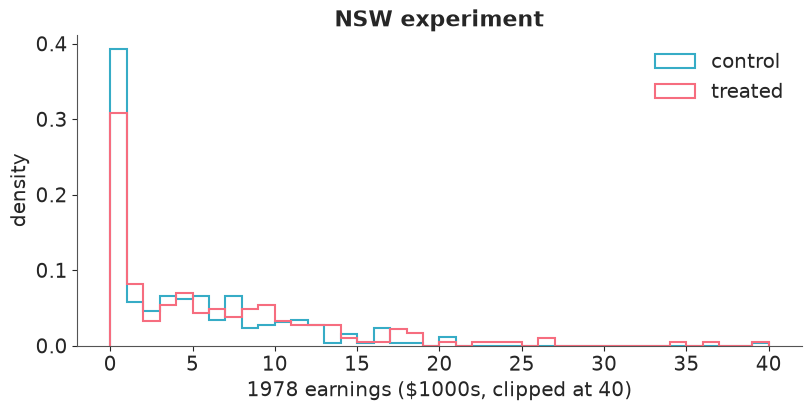

In [4]:
COVARIATES = ["age", "educ", "black", "hisp", "marr", "nodegree", "re74", "re75"]
ARMS = ["control", "treated"]

fig, ax = plt.subplots(figsize=(8, 4))
bins = np.linspace(0, 40, 41)
for arm, grp in nsw.groupby("treat"):
    ax.hist(grp.re78.clip(upper=40_000) / 1000, bins=bins, histtype="step", lw=1.5, density=True, label=ARMS[arm])
ax.set(xlabel="1978 earnings ($1000s, clipped at 40)", ylabel="density", title="NSW experiment")
ax.legend()

nsw.groupby("treat").re78.agg(
    n="size", share_zero=lambda s: (s == 0).mean(), median="median", mean="mean", max="max"
).round(2)

In [5]:
nsw.groupby("treat")[COVARIATES].mean().T.round(2)

treat,0,1
age,25.05,25.82
educ,10.09,10.35
black,0.83,0.84
hisp,0.11,0.06
marr,0.15,0.19
nodegree,0.83,0.71
re74,2107.03,2095.57
re75,1266.91,1532.06


A quarter to a third of the men earned **exactly nothing** in 1978 (35% of controls, 24% of
the trained), the rest are strongly right-skewed, and one man earned $60,000. A Normal
puts mass on negative earnings and no point mass at zero; Gamma and LogNormal cannot
produce an exact zero at all. The outcome is really two outcomes: *did he work?* and *how
much did he earn if so?*

The covariate means of the two arms agree closely, as randomisation promises (`nodegree`
differs a little - chance, with 445 people). Also note who these men are: average
pre-programme earnings of about $2,100 in 1974, and most of them earned nothing.

## Task 1 · The experimental benchmark

Because of randomisation, the difference between the arms is the causal effect of training
for men like these. Estimate it properly.

**Deliver**
1. A Bayesian model of `re78` by arm with the most obvious likelihood, and a posterior
   predictive check that shows specifically what it gets wrong.
2. A better likelihood, with priors you can defend on the dollar scale, clean diagnostics,
   and a posterior predictive check that passes where the first failed.
3. The posterior of the **average treatment effect in dollars** (difference in *mean*
   earnings, zeros included), with a 94% interval and the probability that it exceeds
   $1,000 a year. This is the benchmark for everything that follows.

### Solution

We work in **thousands of dollars**. First the model everyone writes: Normal earnings with
a mean per arm.

In [6]:
warnings.filterwarnings("ignore", message=".*No safe default transform.*")  # HurdleGamma is a mixture; harmless here

t_exp = nsw.treat.values
y_exp = nsw.re78.values / 1000

with pm.Model(coords={"arm": ARMS}) as normal_model:
    mean = pm.Normal("mean", 5, 5, dims="arm")
    sigma = pm.HalfNormal("sigma", 10)
    pm.Deterministic("ate", mean[1] - mean[0])
    pm.Normal("re78", mean[t_exp], sigma, observed=y_exp)
    normal_idata = pm.sample(random_seed=RANDOM_SEED)
    pm.sample_posterior_predictive(normal_idata, extend_inferencedata=True, random_seed=RANDOM_SEED)

az.summary(normal_idata, var_names=["mean", "sigma", "ate"], ci_kind="hdi", ci_prob=0.94, round_to=2)

NUTS[nutpie]: [mean, sigma]


Sampling: [re78]


,mean,sd,hdi94_lb,hdi94_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
mean[control],4.56,0.40,3.81,5.30,6192.29,3155.98,1.0,0.01,0.01
mean[treated],6.34,0.49,5.42,7.23,6259.56,3120.36,1.0,0.01,0.01
sigma,6.59,0.22,6.19,7.01,6386.21,3503.90,1.0,0.00,0.00
ate,1.78,0.63,0.55,2.92,6200.97,3170.18,1.0,0.01,0.01


A **hurdle** model matches the two-part story from Task 0: with probability $\psi$ a man
has positive earnings, and if so they are Gamma distributed with mean $\mu$. Mean earnings
including the zeros are then $\psi\mu$, and the ATE is the difference of that product
between arms.

Priors, on the $1000 scale: a full-time minimum-wage job paid about $5,500 a year in 1978,
and these are men on the margins of the labour market, so `Gamma(mu=8, sigma=5)` for mean
positive earnings covers roughly 1.5 to 19. `Beta(2, 2)` on $\psi$ says only "not 0, not 1".
The prior predictive check below turns those into an implied prior on the ATE.

In [7]:
with pm.Model(coords={"arm": ARMS}) as hurdle_model:
    psi = pm.Beta("psi", 2, 2, dims="arm")
    mu_pos = pm.Gamma("mu_pos", mu=8, sigma=5, dims="arm")
    shape = pm.Gamma("shape", mu=1.5, sigma=1)
    mean = pm.Deterministic("mean", psi * mu_pos, dims="arm")
    pm.Deterministic("ate", mean[1] - mean[0])
    pm.HurdleGamma("re78", psi=psi[t_exp], alpha=shape, beta=shape / mu_pos[t_exp], observed=y_exp)
    hurdle_prior = pm.sample_prior_predictive(1000, random_seed=RANDOM_SEED)

prior_ate = hurdle_prior.prior["ate"].values.ravel()
print("prior 94% interval for the ATE ($1000s):", np.quantile(prior_ate, [0.03, 0.97]).round(1))
print("prior 94% interval for mean earnings   :", np.quantile(hurdle_prior.prior["mean"].values, [0.03, 0.97]).round(1))

Sampling: [mu_pos, psi, re78, shape]


prior 94% interval for the ATE ($1000s): [-9.6  8.6]
prior 94% interval for mean earnings   : [ 0.4 11.6]


In [8]:
with hurdle_model:
    hurdle_idata = pm.sample(random_seed=RANDOM_SEED)
    pm.sample_posterior_predictive(hurdle_idata, extend_inferencedata=True, random_seed=RANDOM_SEED)

print("divergences:", int(hurdle_idata.sample_stats["diverging"].sum()))
az.summary(hurdle_idata, ci_kind="hdi", ci_prob=0.94, round_to=2)

NUTS[nutpie]: [psi, mu_pos, shape]


Sampling: [re78]


divergences: 0


,mean,sd,hdi94_lb,hdi94_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
psi[control],0.64,0.03,0.59,0.70,6121.91,3539.34,1.0,0.00,0.00
psi[treated],0.75,0.03,0.69,0.81,6178.58,3042.08,1.0,0.00,0.00
mu_pos[control],7.08,0.46,6.23,7.93,6285.15,3172.72,1.0,0.01,0.01
mu_pos[treated],8.41,0.60,7.30,9.47,6367.59,3447.37,1.0,0.01,0.01
shape,1.42,0.10,1.22,1.61,5963.90,3563.19,1.0,0.00,0.00
mean[control],4.56,0.36,3.91,5.23,6187.43,3488.66,1.0,0.00,0.01
mean[treated],6.32,0.52,5.37,7.31,6636.87,3136.63,1.0,0.01,0.01
ate,1.76,0.64,0.66,3.06,6935.91,3041.33,1.0,0.01,0.01


Normal         zeros: observed 0.31, replicated 0.00 | negative: replicated 0.21 | 99th pct: observed 26.6, replicated 20.8
Hurdle-Gamma   zeros: observed 0.31, replicated 0.31 | negative: replicated 0.00 | 99th pct: observed 26.6, replicated 28.7


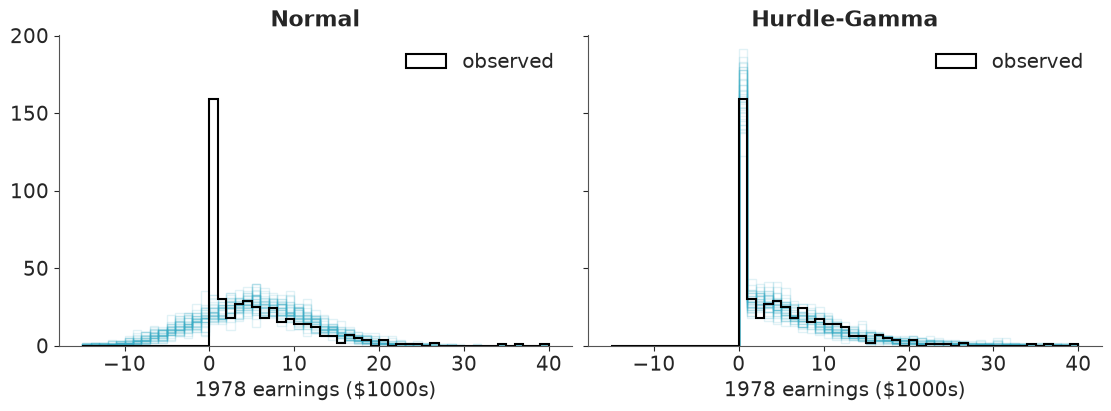

In [9]:
def ppc_panel(ax, idata, title):
    """Replicated histograms against the observed one, plus the two statistics that matter."""
    rep = az.extract(idata, group="posterior_predictive", var_names="re78", num_samples=200, random_seed=RANDOM_SEED)
    rep = rep.values.T  # (draws, obs)
    bins = np.linspace(-15, 40, 56)
    for r in rep[:40]:
        ax.hist(r, bins=bins, histtype="step", color="C0", alpha=0.15)
    ax.hist(y_exp, bins=bins, histtype="step", color="k", lw=1.5, label="observed")
    ax.set(xlabel="1978 earnings ($1000s)", title=title)
    ax.legend()
    print(
        f"{title:<14} zeros: observed {np.mean(y_exp == 0):.2f}, replicated {np.mean(rep == 0):.2f} | "
        f"negative: replicated {np.mean(rep < 0):.2f} | "
        f"99th pct: observed {np.quantile(y_exp, 0.99):.1f}, replicated {np.quantile(rep, 0.99):.1f}"
    )


fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
ppc_panel(axes[0], normal_idata, "Normal")
ppc_panel(axes[1], hurdle_idata, "Hurdle-Gamma")

In [10]:
ate_exp = hurdle_idata.posterior["ate"]  # $1000s
print(f"experimental ATE: ${1000 * float(ate_exp.mean()):,.0f}")
print("94% interval ($):", (1000 * np.quantile(ate_exp, [0.03, 0.97])).round(0))
print(f"P(ATE > $1,000) = {float((ate_exp > 1).mean()):.2f}")
print(f"raw difference in means: ${1000 * (y_exp[t_exp == 1].mean() - y_exp[t_exp == 0].mean()):,.0f}")

experimental ATE: $1,762
94% interval ($): [ 598. 3004.]
P(ATE > $1,000) = 0.89
raw difference in means: $1,794


In [11]:
assert h.check("task1", ate=1000 * ate_exp.mean(), p_ate_gt_1000=(ate_exp > 1).mean())

- PASS `ate` = 1762 is consistent with the reference solution.
- PASS `p_ate_gt_1000` = 0.89 is consistent with the reference solution.

The Normal model predicts that about a fifth of the men earn *negative* amounts and nobody
earns exactly zero; the hurdle model reproduces the 31% of zeros and the right tail. Both
give nearly the same ATE, because a difference in means is robust to the likelihood - but
only the hurdle model tells the ministry *how* training works: about half of the effect is
more men in work ($\psi$ rises from 0.64 to 0.75) and half is higher earnings among those
who work (from about $7,100 to $8,400).

**The benchmark: training raised 1978 earnings by about $1,750, 94% interval roughly $600
to $3,000, and the probability that the effect exceeds $1,000 is about 0.89.** Because
assignment was random this is also the effect *on the treated* (the ATT), which is what the
observational analysis below can hope to estimate.

## Task 2 · The ministry's dataset

Now forget the experimental controls. The ministry has the 185 participants and the CPS.

**Deliver**
1. The observational dataset (NSW treated + all CPS men) and the naive estimate: the
   difference in mean 1978 earnings between participants and non-participants.
2. A covariate balance table - means by group and **standardised mean differences** - side
   by side with the same table for the experiment.
3. A short paragraph for the ministry explaining why the naive number says nothing about
   the programme. Look closely at the CPS earnings columns too: is there anything about how
   they were recorded that a model should know?

In [12]:
treated = nsw[nsw.treat == 1]
obs = pd.concat([treated, cps], ignore_index=True)

naive = obs.re78[obs.treat == 1].mean() - obs.re78[obs.treat == 0].mean()
print(f"naive difference in means: ${naive:,.0f}")


def smd(a, b):
    """Standardised mean difference: (mean_a - mean_b) / pooled sd."""
    return (a.mean() - b.mean()) / np.sqrt((a.var() + b.var()) / 2)


exp_controls = nsw[nsw.treat == 0]
balance = pd.DataFrame(
    {
        "NSW treated": treated[COVARIATES].mean(),
        "NSW controls": exp_controls[COVARIATES].mean(),
        "CPS": cps[COVARIATES].mean(),
        "SMD vs NSW controls": [smd(treated[c], exp_controls[c]) for c in COVARIATES],
        "SMD vs CPS": [smd(treated[c], cps[c]) for c in COVARIATES],
    }
)
balance.round(2)

naive difference in means: $-8,498


,NSW treated,NSW controls,CPS,SMD vs NSW controls,SMD vs CPS
age,25.82,25.05,33.23,0.11,-0.80
educ,10.35,10.09,12.03,0.14,-0.68
black,0.84,0.83,0.07,0.04,2.43
hisp,0.06,0.11,0.07,-0.17,-0.05
marr,0.19,0.15,0.71,0.09,-1.23
nodegree,0.71,0.83,0.30,-0.30,0.90
re74,2095.57,2107.03,14016.80,-0.00,-1.57
re75,1532.06,1266.91,13650.80,0.08,-1.75


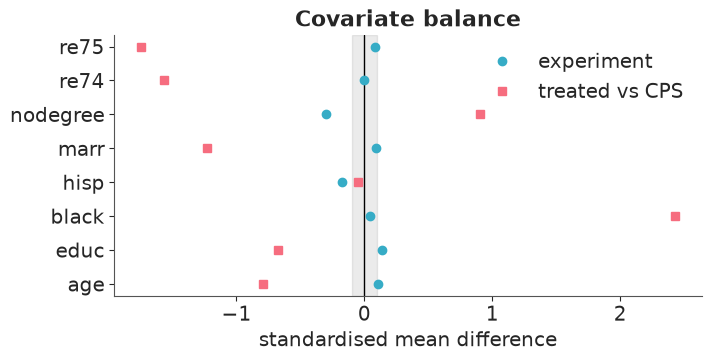

In [13]:
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.axvline(0, color="k", lw=1)
ax.axvspan(-0.1, 0.1, color="k", alpha=0.08)
ax.plot(balance["SMD vs NSW controls"], COVARIATES, "o", label="experiment")
ax.plot(balance["SMD vs CPS"], COVARIATES, "s", label="treated vs CPS")
ax.set(xlabel="standardised mean difference", title="Covariate balance")
ax.legend();

In [14]:
profile = lambda d: (d.black == 1) & (d.marr == 0) & (d.re74 == 0) & (d.re75 == 0)
print(f"Black, unmarried, no earnings in 1974 or 1975: {profile(treated).sum()} of {len(treated)} participants, "
      f"{profile(cps).sum()} of {len(cps):,} CPS men")
for col in ["re74", "re75", "re78"]:
    top = cps[col].max()
    print(f"CPS {col}: max {top:,.0f}, share exactly at the max {np.mean(cps[col] == top):.2f}")

Black, unmarried, no earnings in 1974 or 1975: 81 of 185 participants, 58 of 15,992 CPS men
CPS re74: max 25,862, share exactly at the max 0.19
CPS re75: max 25,244, share exactly at the max 0.19
CPS re78: max 25,565, share exactly at the max 0.26


In [15]:
assert h.check("task2", naive_diff=naive, smd_black=balance.loc["black", "SMD vs CPS"])

- PASS `naive_diff` = -8498 is consistent with the reference solution.
- PASS `smd_black` = 2.428 is consistent with the reference solution.

The naive comparison says training *costs* a man $8,500 a year. It is a comparison of two
different populations. Rule of thumb: an SMD beyond ±0.1 is worth worrying about. The
experiment stays inside ±0.3; against the CPS, *every* covariate except `hisp` is off by
0.7 to 2.4 standard deviations. Participants are 84% Black (CPS: 7%), 19% married (71%),
and earned $2,100 in 1974 against $14,000. The programme **selected** men with poor
earnings prospects, so they would have earned less than the average CPS man in 1978 with
or without training. Only 58 of the 15,992 CPS men share the most common participant
profile.

Two more things a careful analyst notices. CPS earnings are **top-coded**: a quarter of CPS
men sit exactly at $25,565 in 1978 (and a fifth at the cap in 1974-75), so the CPS outcome is
censored where the participants are not. And the two groups' earnings come from different
sources (programme records versus a household survey). Neither problem can be fixed by
regression; both matter less the more we restrict attention to low-earning CPS men.

## Task 3 · A causal model, conditioned and intervened on

**Deliver**
1. The causal DAG you are assuming, drawn in a markdown cell, with the adjustment set it
   implies and the assumptions that are *not* testable from these data.
2. **One** generative PyMC model of the observational data - treatment assignment *and*
   1978 earnings given the covariates - written without any observed data. Condition it on
   the data with `pm.observe`, fit it, and then use `pm.do` to set `treat` to 0 and to 1
   for the participants. From those two interventions compute the posterior of the
   **ATT** (average effect on the 185 participants) by g-computation.
3. Compare with the benchmark. How far off is it, and in which direction?

Use all 16,177 rows here. Sampling takes around a minute; storing a 16,177-long
deterministic for every draw is what you need to avoid.

### Solution

```
            X = {age, educ, black, hisp, marr, nodegree, re74, re75}
             │                                   │
             ▼                                   ▼
          treat  ───────────────────────────►  re78
             ▲                                   ▲
             └ ─ ─ ─ ─ ─ ─ ─   U   ─ ─ ─ ─ ─ ─ ─ ┘
                (motivation, health, local labour market, ...)
```

Every covariate is measured **before** treatment, plausibly affects both who ends up in the
programme and what they earn later, and cannot be affected by the programme. Conditioning
on all of $X$ closes every back-door path `treat ← X → re78`, so the adjustment set is all
eight covariates. Pre-programme earnings do the heavy lifting: they are the best available
proxy for the unobservables $U$.

Untestable assumptions: (1) **no unmeasured confounding** - the dashed $U$ paths are absent
once we condition on $X$; (2) **positivity** - for every kind of participant there are
comparable non-participants (we will test this one in Task 4, and it fails); (3) the
outcome means the same thing in both data sources.

The generative model has two parts: a logistic model for who gets treated and the
hurdle-Gamma earnings model from Task 1, now with covariates and a treatment effect on both
the probability of working and the level of earnings. Writing it as a function of a
data frame means the *same* code describes any population we want to intervene on.

In [16]:
def features(df, names):
    """Design matrix on scales where Normal(0, 1) priors are weakly informative."""
    d = pd.DataFrame(index=df.index)
    d["age"] = (df.age - 30) / 10
    d["educ"] = (df.educ - 11) / 3
    for col in ["black", "hisp", "marr", "nodegree"]:
        d[col] = df[col].astype(float)
    d["re74"] = df.re74 / 10_000
    d["re75"] = df.re75 / 10_000
    d["age2"] = d.age**2
    d["u74"] = (df.re74 == 0).astype(float)  # no earnings at all in 1974
    d["u75"] = (df.re75 == 0).astype(float)
    return d[list(names)]


def generative(df, names):
    """Generative model of (treat, re78) given covariates. Nothing is observed yet."""
    X = features(df, names).values
    with pm.Model(coords={"obs": df.index.values, "cov": list(names)}) as gen:
        # who gets treated
        g0 = pm.Normal("g0", 0, 3)
        g = pm.Normal("g", 0, 2, dims="cov")
        treat = pm.Bernoulli("treat", logit_p=g0 + pm.math.dot(X, g), dims="obs")
        # what they earn: P(any earnings) and mean earnings if positive ($1000s)
        a_z = pm.Normal("a_z", 0, 2)
        b_z = pm.Normal("b_z", 0, 1, dims="cov")
        tau_z = pm.Normal("tau_z", 0, 1)
        a_m = pm.Normal("a_m", 2, 1)
        b_m = pm.Normal("b_m", 0, 1, dims="cov")
        tau_m = pm.Normal("tau_m", 0, 1)
        shape = pm.Gamma("shape", mu=1.5, sigma=1)
        psi = pm.math.sigmoid(a_z + tau_z * treat + pm.math.dot(X, b_z))
        mu = pm.math.exp(a_m + tau_m * treat + pm.math.dot(X, b_m))
        pm.Deterministic("expected", psi * mu, dims="obs")  # E[re78 | treat, X]
        pm.HurdleGamma("re78", psi=psi, alpha=shape, beta=shape / mu, dims="obs")
    return gen


PARAMETERS = ["g0", "g", "a_z", "b_z", "tau_z", "a_m", "b_m", "tau_m", "shape"]
logging.getLogger("pymc.sampling.forward").setLevel(logging.WARNING)  # silence "Sampling: []" below


def fit(df, names):
    """Condition the generative model on the data and sample. Only parameters are stored."""
    conditioned = pm.observe(generative(df, names), {"treat": df.treat.values, "re78": df.re78.values / 1000})
    with conditioned:
        idata = pm.sample(var_names=PARAMETERS, nuts_sampler="nutpie", random_seed=RANDOM_SEED)
    worst = az.summary(idata)
    print(f"n = {len(df):,}: divergences {int(idata.sample_stats['diverging'].sum())}, "
          f"max r_hat {worst.r_hat.max():.3f}, min ESS {worst.ess_bulk.min():.0f}")
    return idata


def expected_under(idata, df, names, treat_value):
    """Posterior of E[re78 | do(treat = treat_value), X_i] for every row of df."""
    intervened = pm.do(generative(df, names), {"treat": np.full(len(df), treat_value)})
    with intervened:
        pp = pm.sample_posterior_predictive(
            idata, var_names=["expected"], random_seed=RANDOM_SEED, progressbar=False
        )
    return pp.posterior_predictive["expected"]


def att(idata, names):
    """g-computation: average over the participants of E[Y | do(1), X] - E[Y | do(0), X]."""
    return (expected_under(idata, treated, names, 1) - expected_under(idata, treated, names, 0)).mean("obs")


def describe(label, draws):
    v = 1000 * np.asarray(draws).ravel()
    lo, hi = np.quantile(v, [0.03, 0.97])
    return {"analysis": label, "mean": v.mean(), "sd": v.std(), "lo94": lo, "hi94": hi, "P(>$1,000)": np.mean(v > 1000)}

`pm.observe` turns the named random variables into observed ones; `pm.do` replaces a random
variable by a constant, cutting the arrow from $X$ into `treat`. Because `pm.do` is applied
to the generative model built on the **participants' rows**, sampling `expected` from it
with the fitted posterior gives the participants' potential outcomes directly.

The first attempt adjusts linearly (on the link scales) for the eight covariates.

In [17]:
BASE = COVARIATES
full_idata = fit(obs, BASE)
att_full = att(full_idata, BASE)

results = [describe("experiment (benchmark)", ate_exp), describe("full CPS, linear adjustment", att_full)]
pd.DataFrame(results).set_index("analysis").round({"mean": 0, "sd": 0, "lo94": 0, "hi94": 0, "P(>$1,000)": 2})

NUTS[nutpie]: [b_m, g, g0, tau_m, a_m, b_z, tau_z, a_z, shape]


n = 16,177: divergences 0, max r_hat 1.006, min ESS 2088


,mean,sd,lo94,hi94,"P(>$1,000)"
analysis,,,,,
experiment (benchmark),1762.0,638.0,598.0,3004.0,0.89
"full CPS, linear adjustment",74.0,432.0,-707.0,897.0,0.02


In [18]:
assert h.check("task3", att_full=1000 * att_full.mean())

- PASS `att_full` = 73.67 is consistent with the reference solution.

Regression adjustment has moved the estimate from −$8,500 to about **zero** - an
improvement of eight thousand dollars, and still the wrong answer: the model is confident
(sd about $430) that the effect is below $1,000, while the experiment says it is probably
above. The sampler is perfectly happy. Nothing in `r_hat` or ESS can tell you that a causal
estimate is wrong.

## Task 4 · Where do the counterfactuals come from?

The ATT needs, for each participant, a prediction of what he would have earned *without*
training. Those predictions are only as good as the non-participants who resemble him.

**Deliver**
1. A diagnosis: estimate every man's probability of being a participant given his
   covariates (the **propensity score** - you may already have it) and compare its
   distribution in the two groups. What share of the CPS has a propensity below 1%?
2. Evidence, *not using the experimental controls*, that the Task 3 outcome model is wrong
   in the region of covariate space where the participants live.
3. A fix, a refit with clean diagnostics, and the new ATT next to the benchmark. State
   exactly which population your new estimate refers to.

### Solution

The treatment part of the generative model *is* a propensity model, and it was fitted along
with everything else. To give it a fair chance of separating the groups we use a richer
covariate set from here on: a quadratic in age and indicators for zero earnings in 1974 and
1975 (being out of work is qualitatively different from earning little).

NUTS[nutpie]: [b_m, g, g0, tau_m, a_m, b_z, tau_z, a_z, shape]


n = 16,177: divergences 0, max r_hat 1.003, min ESS 1623


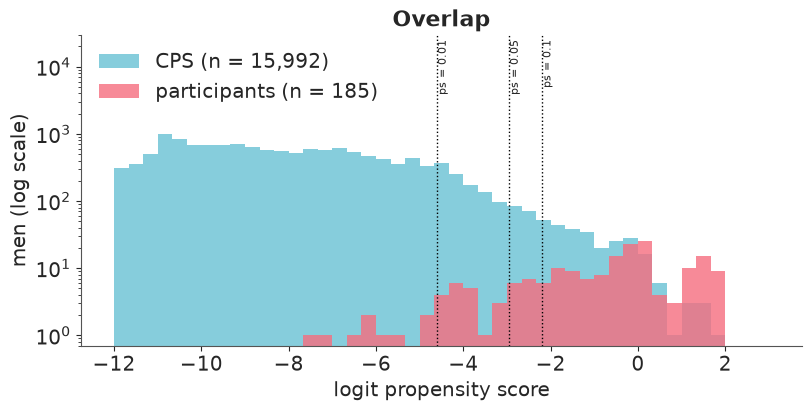

In [19]:
FLEX = BASE + ["age2", "u74", "u75"]
flex_idata = fit(obs, FLEX)
att_flex = att(flex_idata, FLEX)


def propensity(idata, df, names):
    post = az.extract(idata, var_names=["g0", "g"], num_samples=400, random_seed=RANDOM_SEED)
    logit = post["g0"].values[None, :] + features(df, names).values @ post["g"].transpose("cov", "sample").values
    return expit(logit).mean(axis=1)


obs["ps"] = propensity(flex_idata, obs, FLEX)
is_treated = obs.treat == 1

fig, ax = plt.subplots(figsize=(8, 4))
bins = np.linspace(-12, 3, 46)
logit_ps = np.log(obs.ps / (1 - obs.ps))
ax.hist(logit_ps[~is_treated], bins=bins, alpha=0.6, label=f"CPS (n = {(~is_treated).sum():,})")
ax.hist(logit_ps[is_treated], bins=bins, alpha=0.8, label=f"participants (n = {is_treated.sum()})")
for p in (0.01, 0.05, 0.1):
    ax.axvline(np.log(p / (1 - p)), color="k", ls=":", lw=1)
    ax.text(np.log(p / (1 - p)), 25_000, f" ps = {p:g}", rotation=90, va="top", fontsize=8)
ax.set(yscale="log", ylim=(0.7, 30_000), xlabel="logit propensity score", ylabel="men (log scale)", title="Overlap")
ax.legend(loc="upper left");

In [20]:
share_below = np.mean(obs.ps[~is_treated] < 0.01)
print(f"share of CPS men with propensity below 1%: {share_below:.3f}")
overlap = pd.DataFrame(
    {
        "CPS kept": [int(((obs.ps >= p) & ~is_treated).sum()) for p in (0.01, 0.05, 0.1)],
        "participants above": [int(((obs.ps >= p) & is_treated).sum()) for p in (0.01, 0.05, 0.1)],
    },
    index=pd.Index([0.01, 0.05, 0.1], name="propensity >="),
)
print(f"propensity above 0.5: {((obs.ps > 0.5) & is_treated).sum()} participants, "
      f"{((obs.ps > 0.5) & ~is_treated).sum()} CPS men")
overlap

share of CPS men with propensity below 1%: 0.913
propensity above 0.5: 66 participants, 30 CPS men


,CPS kept,participants above
propensity >=,,
0.01,1393,175
0.05,404,157
0.10,256,142


More than nine CPS men in ten have less than a 1% chance of being a participant: they are
older, married, steadily employed men who tell us nothing about the counterfactual of an
unemployed 25-year-old. Yet they are 90% of the likelihood, so *they* decide the
regression coefficients, and the participants' counterfactuals are an extrapolation of a
curve fitted elsewhere.

That can be checked without the experiment. If the outcome model is right, it should
predict the 1978 earnings of the few CPS men who *do* look like participants:

In [21]:
lookalikes = obs[(obs.ps >= 0.05) & ~is_treated]
print(f"{len(lookalikes)} CPS look-alikes earned ${lookalikes.re78.mean():,.0f} on average in 1978 "
      f"(standard error ${lookalikes.re78.std() / np.sqrt(len(lookalikes)):,.0f})")
for label, idata, names in [("linear", full_idata, BASE), ("flexible", flex_idata, FLEX)]:
    pred = expected_under(idata, lookalikes, names, 0).mean("obs")
    print(f"{label:>9} full-sample model predicts ${1000 * float(pred.mean()):,.0f} for them "
          f"(94% interval {(1000 * np.quantile(pred, [0.03, 0.97])).round(0)})")

404 CPS look-alikes earned $5,666 on average in 1978 (standard error $324)
   linear full-sample model predicts $6,682 for them (94% interval [6389. 6981.])


 flexible full-sample model predicts $6,384 for them (94% interval [6085. 6689.])


**The fix is to stop asking the model to extrapolate**: keep all participants (so the
estimand stays the ATT for the 185 men) but only those CPS men with a propensity of at
least 5%, and refit the same generative model on that common-support sample.

In [22]:
def trimmed(threshold):
    return obs[(obs.ps >= threshold) | is_treated]


trim_df = trimmed(0.05)
print(f"controls kept: {(trim_df.treat == 0).sum()}, "
      f"of which top-coded: {np.mean(trim_df.re78[trim_df.treat == 0] >= cps.re78.max()):.3f}")
balance_trim = pd.DataFrame(
    {
        "SMD vs all CPS": balance["SMD vs CPS"],
        "SMD vs trimmed CPS": [smd(treated[c], trim_df.loc[trim_df.treat == 0, c]) for c in COVARIATES],
    }
)
balance_trim.round(2)

controls kept: 404, of which top-coded: 0.007


,SMD vs all CPS,SMD vs trimmed CPS
age,-0.80,-0.00
educ,-0.68,-0.03
black,2.43,-0.09
hisp,-0.05,-0.14
marr,-1.23,-0.13
nodegree,0.90,0.18
re74,-1.57,-0.24
re75,-1.75,-0.19


In [23]:
trim_idata = fit(trim_df, FLEX)
att_trim = att(trim_idata, FLEX)

results += [describe("full CPS, flexible adjustment", att_flex), describe("trimmed (ps >= 0.05), flexible", att_trim)]
pd.DataFrame(results).set_index("analysis").round({"mean": 0, "sd": 0, "lo94": 0, "hi94": 0, "P(>$1,000)": 2})

NUTS[nutpie]: [b_m, g, g0, tau_m, a_m, b_z, tau_z, a_z, shape]


n = 589: divergences 0, max r_hat 1.002, min ESS 1735


,mean,sd,lo94,hi94,"P(>$1,000)"
analysis,,,,,
experiment (benchmark),1762.0,638.0,598.0,3004.0,0.89
"full CPS, linear adjustment",74.0,432.0,-707.0,897.0,0.02
"full CPS, flexible adjustment",851.0,435.0,70.0,1673.0,0.36
"trimmed (ps >= 0.05), flexible",1030.0,773.0,-371.0,2467.0,0.51


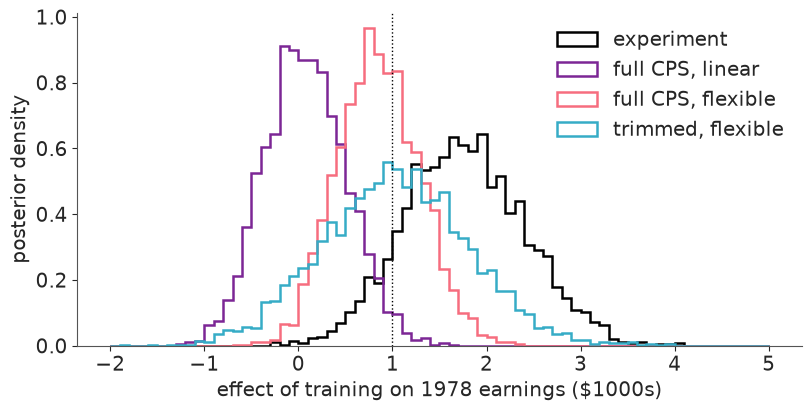

In [24]:
fig, ax = plt.subplots(figsize=(8, 4))
bins = np.linspace(-2, 5, 71)
for label, draws, color in [
    ("experiment", ate_exp, "k"),
    ("full CPS, linear", att_full, "C3"),
    ("full CPS, flexible", att_flex, "C1"),
    ("trimmed, flexible", att_trim, "C0"),
]:
    ax.hist(np.asarray(draws).ravel(), bins=bins, histtype="step", lw=1.8, density=True, color=color, label=label)
ax.axvline(1, color="k", ls=":", lw=1)
ax.set(xlabel="effect of training on 1978 earnings ($1000s)", ylabel="posterior density")
ax.legend();

In [25]:
assert h.check("task4", cps_share_below_1pct=share_below, att_trimmed=1000 * att_trim.mean())

- PASS `cps_share_below_1pct` = 0.9129 is consistent with the reference solution.
- PASS `att_trimmed` = 1030 is consistent with the reference solution.

Both full-sample models over-predict what the look-alike CPS men earned by $700 to $1,000,
two to three standard errors of that average: the fit is dominated by men elsewhere in
covariate space. Over-predicting the untreated outcome of men like the participants is exactly what
biases the ATT downwards.

After trimming, 404 of the 15,992 CPS men remain. Every SMD is now within ±0.25 (it was up
to 2.4), and fewer than 1% of the remaining controls are top-coded, so that problem has
gone too. The estimates move in the right direction at each step - about $70 with the
linear full-sample model, $850 once age squared and the zero-earnings indicators are
added, $1,030 on the common-support sample - and the posterior sd almost doubles, from
$430 to $770. That is the honest price: the full-sample posterior was narrow because
15,000 irrelevant men were voting.

The benchmark of $1,760 sits comfortably inside the trimmed model's 94% interval (about
−$370 to $2,470), but the point estimate is still $700 short of it, and zero is inside the
interval too. **The estimand** is unchanged - the ATT for all 185 participants - but 28 of
them have a propensity below 0.05 and therefore few close comparisons, and at the other
end (propensity above one half) participants outnumber the CPS men they are compared
with. For those men the model is still doing more work than the data.

## Task 5 · How fragile is the answer?

You made choices in Task 4 that the ministry cannot audit. Show what they are worth.

**Deliver** a table and a plot of the ATT posterior under
1. at least three trimming thresholds, and
2. at least three adjustment sets on your preferred trimmed sample: all covariates, without
   `re74`, and without any pre-programme earnings.

Then answer: which choice matters most, and what does that say about the DAG in Task 3?

In [26]:
NO_RE74 = [c for c in FLEX if c not in ("re74", "u74")]
NO_EARNINGS = [c for c in NO_RE74 if c not in ("re75", "u75")]

sensitivity = {"ps >= 0.05, all covariates": att_trim}
for label, threshold, names in [
    ("ps >= 0.01, all covariates", 0.01, FLEX),
    ("ps >= 0.10, all covariates", 0.10, FLEX),
    ("ps >= 0.05, without re74", 0.05, NO_RE74),
    ("ps >= 0.05, without re74 and re75", 0.05, NO_EARNINGS),
]:
    sensitivity[label] = att(fit(trimmed(threshold), names), names)

sens_table = pd.DataFrame([describe(k, v) for k, v in sensitivity.items()]).set_index("analysis")
sens_table.round({"mean": 0, "sd": 0, "lo94": 0, "hi94": 0, "P(>$1,000)": 2})

NUTS[nutpie]: [b_m, g, g0, tau_m, a_m, b_z, tau_z, a_z, shape]


n = 1,578: divergences 0, max r_hat 1.004, min ESS 1433


NUTS[nutpie]: [b_m, g, g0, tau_m, a_m, b_z, tau_z, a_z, shape]


n = 441: divergences 0, max r_hat 1.003, min ESS 1477


NUTS[nutpie]: [b_m, g, g0, tau_m, a_m, b_z, tau_z, a_z, shape]


n = 589: divergences 0, max r_hat 1.004, min ESS 1363


NUTS[nutpie]: [b_m, g, g0, tau_m, a_m, b_z, tau_z, a_z, shape]


n = 589: divergences 0, max r_hat 1.003, min ESS 1258


,mean,sd,lo94,hi94,"P(>$1,000)"
analysis,,,,,
"ps >= 0.05, all covariates",1030.0,773.0,-371.0,2467.0,0.51
"ps >= 0.01, all covariates",1118.0,650.0,-30.0,2348.0,0.57
"ps >= 0.10, all covariates",1376.0,857.0,-204.0,3031.0,0.66
"ps >= 0.05, without re74",1090.0,715.0,-201.0,2469.0,0.55
"ps >= 0.05, without re74 and re75",235.0,723.0,-1090.0,1673.0,0.14


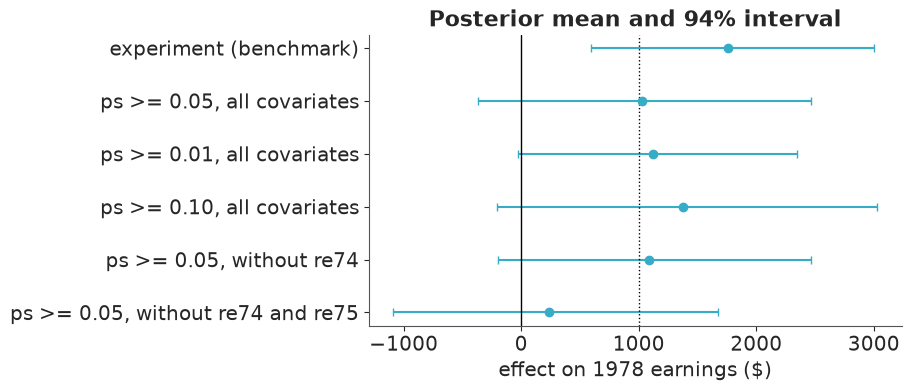

In [27]:
fig, ax = plt.subplots(figsize=(9, 3.8))
rows = pd.concat([pd.DataFrame([describe("experiment (benchmark)", ate_exp)]).set_index("analysis"), sens_table])[::-1]
ypos = np.arange(len(rows))
ax.errorbar(rows["mean"], ypos, xerr=[rows["mean"] - rows["lo94"], rows["hi94"] - rows["mean"]], fmt="o", capsize=3)
ax.axvline(1000, color="k", ls=":", lw=1)
ax.axvline(0, color="k", lw=1)
ax.set_yticks(ypos, rows.index)
ax.set(xlabel="effect on 1978 earnings ($)", title="Posterior mean and 94% interval");

In [28]:
assert h.check("task5", att_no_earnings=1000 * sensitivity["ps >= 0.05, without re74 and re75"].mean())

- PASS `att_no_earnings` = 235.4 is consistent with the reference solution.

**Trimming threshold.** Between 0.01 and 0.10 the posterior mean moves from about $1,030 to
$1,380, much less than one posterior sd ($650 to $860). Every interval contains the
benchmark and every interval contains zero. Tighter trimming trades bias for variance, as
it should.

**Adjustment set.** Dropping `re74` alone changes nothing ($1,090): given `re75`, and given
a sample that was itself selected with a propensity score that knew `re74`, it carries
little extra information here. Dropping *both* years of earnings cuts the estimate to
about $240 and $P(\text{effect} > \$1{,}000)$ from roughly 0.5 to 0.14 - and this
understates their importance, because the trimmed sample was still chosen using them.

So what we adjust for matters more than how we trim. That is a statement about the DAG:
the whole analysis rests on having measured the confounders, and the one time we can test
that - by hiding a confounder we do have - the answer moves by $800. Nothing in the data
says `re75` was the last such variable; programme applicants typically enrol just after
their earnings have dipped, and two years of history may not capture that.

## Task 6 · What do you tell the ministry?

The ministry's economists say the programme pays for itself if it raises participants'
earnings by more than **$1,000 a year** (an illustrative threshold).

**Deliver**
1. $P(\text{effect} > \$1{,}000)$ under the experiment, under the naive full-sample
   adjustment, and under your preferred observational analysis.
2. A short note to the ministry: what the observational data can and cannot support, what
   you would need to see before trusting an observational answer when there is **no**
   experiment to check it against, and whether the memo closing the programme should go out.

In [29]:
decision = pd.DataFrame(
    [
        describe("experiment (benchmark)", ate_exp),
        describe("observational: full CPS, linear", att_full),
        describe("observational: full CPS, flexible", att_flex),
        describe("observational: trimmed, flexible", att_trim),
    ]
).set_index("analysis")
decision.round({"mean": 0, "sd": 0, "lo94": 0, "hi94": 0, "P(>$1,000)": 2})

,mean,sd,lo94,hi94,"P(>$1,000)"
analysis,,,,,
experiment (benchmark),1762.0,638.0,598.0,3004.0,0.89
"observational: full CPS, linear",74.0,432.0,-707.0,897.0,0.02
"observational: full CPS, flexible",851.0,435.0,70.0,1673.0,0.36
"observational: trimmed, flexible",1030.0,773.0,-371.0,2467.0,0.51


In [30]:
assert h.check("task6", p_observational=float((att_trim > 1).mean()))

- PASS `p_observational` = 0.514 is consistent with the reference solution.

**Note to the ministry**

1. *Do not send the memo.* The −$8,500 gap is a comparison of unemployed, mostly unmarried
   25-year-olds with the average American working man. It says nothing about the programme.
2. *Our best observational estimate is about +$1,000 a year* (94% interval roughly −$400 to
   +$2,500). The probability that the programme clears the $1,000 bar is about one half on
   this evidence. The experiment puts it at 0.89, with an estimate of about $1,760. The
   observational analysis gets the sign right and its interval covers the experimental
   answer, but its point estimate is some 40% too low, and we only know that because the
   experiment exists.
3. *The dangerous analysis is the respectable-looking one.* Regression on all 16,000 CPS
   men gave a tight interval around zero, $P = 0.02$, and flawless sampler diagnostics. It
   was confidently wrong, because nine in ten of those men could never have been
   participants and the model extrapolated from them.
4. *None of these intervals includes the uncertainty that matters most* - whether we
   measured everything that drove both enrolment and earnings. Removing pre-programme
   earnings moved the answer by more than any modelling choice did.

Before trusting an observational estimate with no experiment behind it, ask for: overlap
and post-trimming balance; a predictive check of the outcome model on look-alike controls
(Task 4); stability across reasonable thresholds and adjustment sets (Task 5); a placebo
test, such as the "effect" of training on 1975 earnings, which must be zero; and an explicit
statement of how strong an unmeasured confounder would have to be to overturn the decision.
Better still, randomise a pilot.

## Going further

- **Respect the top-coding.** A quarter of CPS men have `re78` recorded at the cap. Model
  that explicitly with a censored likelihood for positive earnings (you will have to split
  the hurdle into its two parts to do it). Does the full-sample estimate move? Does the
  trimmed one?
- **Weight instead of trim.** Use the propensity scores to weight CPS men by
  $e(x) / (1 - e(x))$ in the outcome likelihood (`pm.Potential`), or combine weighting and
  outcome modelling into a doubly-robust estimate. Propagate the uncertainty in $e(x)$.
- **A more flexible response surface.** Replace the linear predictors by an HSGP or BART-like
  additive model in `re74`, `re75` and `age`. Does flexibility substitute for trimming, or
  only hide the extrapolation?
- **Unmeasured confounding.** Add a sensitivity parameter: a latent binary $U$ that raises
  both the odds of participation and earnings. How strong must it be to push
  $P(\text{effect} > \$1{,}000)$ below one half?

In [31]:
h.progress()

**C09**: 0/20 hints used, 9/9 checks passed.